In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
plt.style.use("default")

In [2]:
patients = pd.read_csv(r'D:\DEPI\DEPI final project\data sources\patients.csv')

In [ ]:
patients.BIRTHDATE = pd.to_datetime(patients.BIRTHDATE)
patients.DEATHDATE = pd.to_datetime(patients.DEATHDATE)
today = pd.Timestamp.today()

patients['Age'] = np.where(
    patients.DEATHDATE.notnull(),
    (patients.DEATHDATE - patients.BIRTHDATE).dt.days // 365,
    (today - patients.BIRTHDATE).dt.days // 365
) 

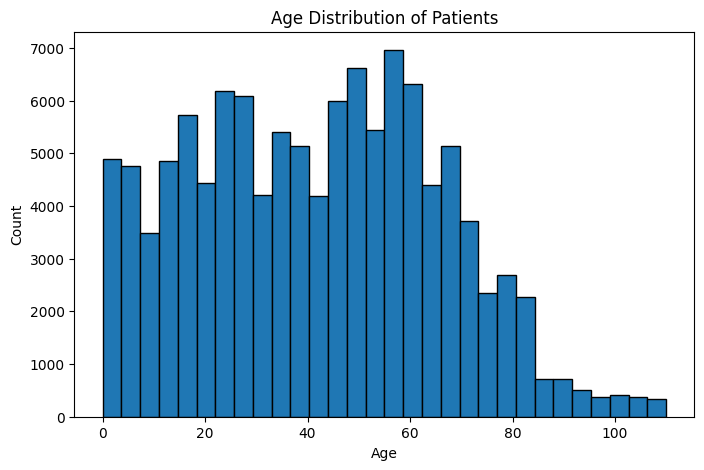

In [29]:
plt.figure(figsize=(8,5))
plt.hist ( patients['Age'].dropna(), bins=30, edgecolor='black')
plt.title('Age Distribution of Patients')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()


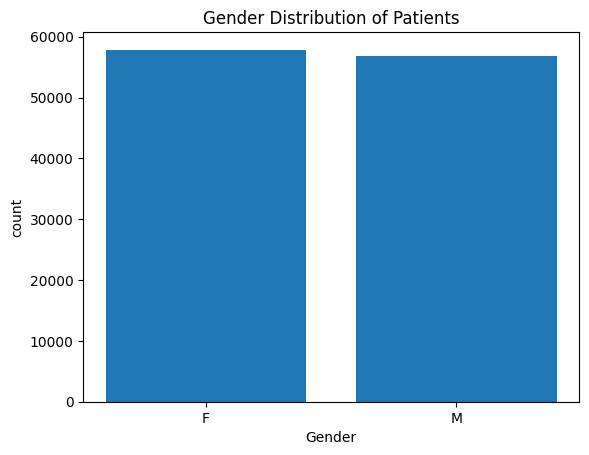

In [28]:
Gender_counts = patients.GENDER.value_counts()
plt.figure()
plt.bar(Gender_counts.index,Gender_counts.values)
plt.title('Gender Distribution of Patients')
plt.xlabel('Gender')
plt.ylabel('count')
plt.show()

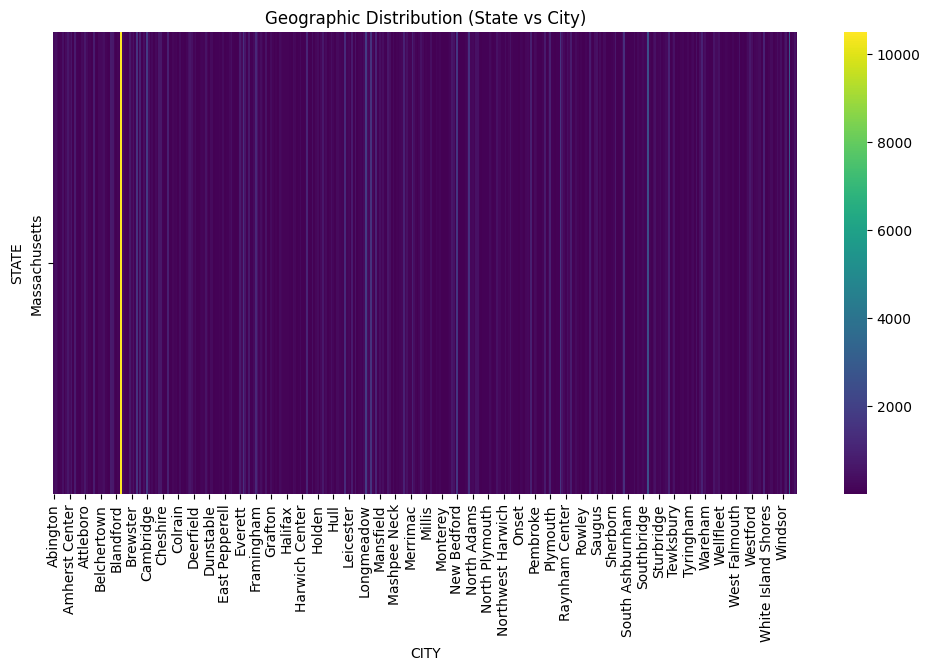

In [40]:
geo = patients.groupby(["STATE", "CITY"]).size().reset_index(name="count")

pivot_geo = geo.pivot(index="STATE", columns="CITY", values="count").fillna(0)

plt.figure(figsize=(12,6))
sns.heatmap(pivot_geo, cmap="viridis")
plt.title("Geographic Distribution (State vs City)")
plt.show()

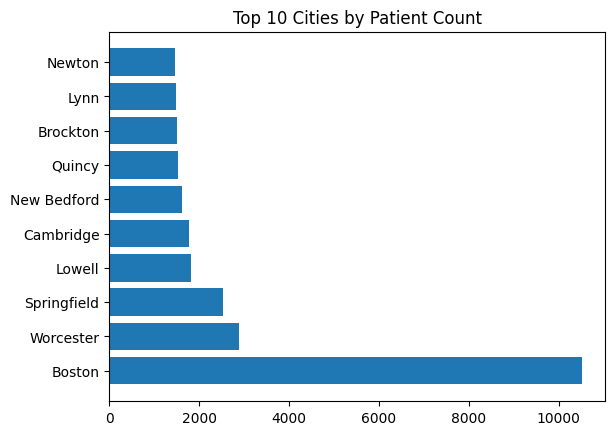

In [38]:
top_cities = patients["CITY"].value_counts().head(10)

plt.figure()
plt.barh(top_cities.index, top_cities.values)
plt.title("Top 10 Cities by Patient Count")
plt.show()

In [42]:
conditions = pd.read_csv(r"D:\DEPI\DEPI final project\data sources\conditions.csv")
conditions.info()
conditions.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 4121052 entries, 0 to 4121051
Data columns (total 7 columns):
 #   Column       Dtype
---  ------       -----
 0   START        str  
 1   STOP         str  
 2   PATIENT      str  
 3   ENCOUNTER    str  
 4   SYSTEM       str  
 5   CODE         int64
 6   DESCRIPTION  str  
dtypes: int64(1), str(6)
memory usage: 220.1 MB


START                0
STOP           1056856
PATIENT              0
ENCOUNTER            0
SYSTEM               0
CODE                 0
DESCRIPTION          0
dtype: int64

In [43]:
conditions.head()

,START,STOP,PATIENT,ENCOUNTER,SYSTEM,CODE,DESCRIPTION
0,2025-07-09,2025-07-09,d54bbddf-1ab7-d6b1-1964-f12313ec0729,d54bbddf-1ab7-d6b1-a49a-24e20ddc7100,SNOMED-CT,314529007,Medication review due (situation)
1,2025-08-13,2025-10-15,d54bbddf-1ab7-d6b1-1964-f12313ec0729,d54bbddf-1ab7-d6b1-09c5-f80dba9f2a9d,SNOMED-CT,314529007,Medication review due (situation)
2,2025-12-17,NaN,d54bbddf-1ab7-d6b1-1964-f12313ec0729,d54bbddf-1ab7-d6b1-7a19-8ddc742f961b,SNOMED-CT,314529007,Medication review due (situation)
3,2015-08-15,2016-08-20,2e6bf760-653f-e325-b20d-ebd85714d951,2e6bf760-653f-e325-176c-fd561c3c03dd,SNOMED-CT,314529007,Medication review due (situation)
4,2016-05-19,2016-06-04,2e6bf760-653f-e325-b20d-ebd85714d951,2e6bf760-653f-e325-1235-03978eff7331,SNOMED-CT,444814009,Viral sinusitis (disorder)


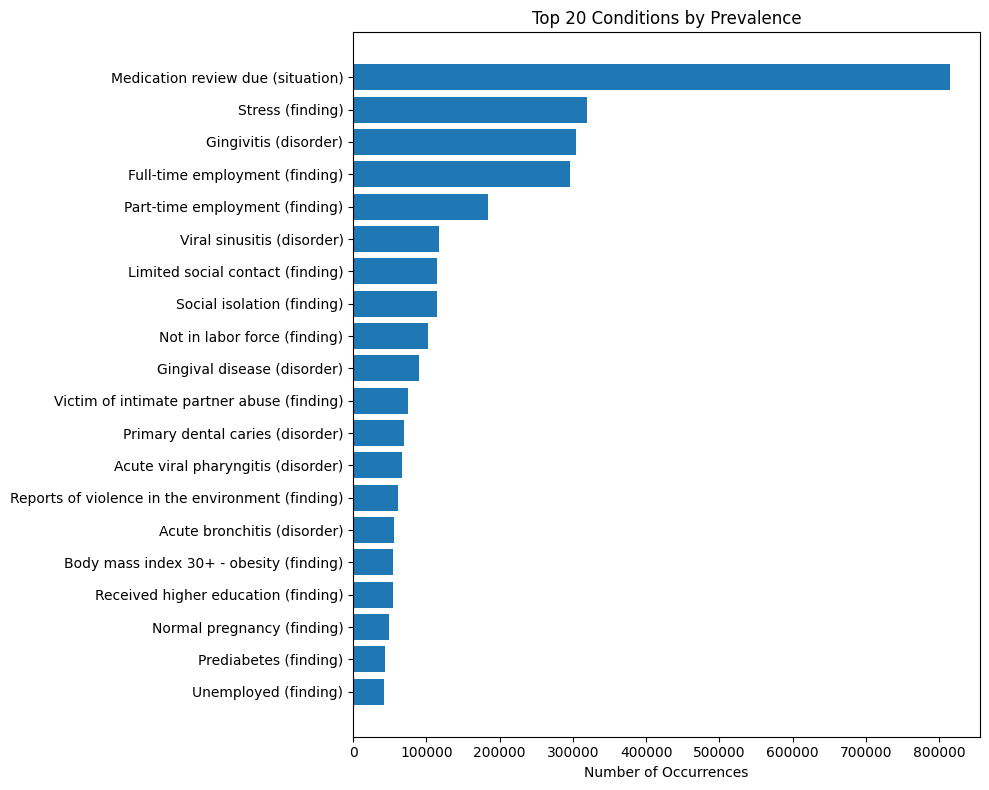

In [ ]:
top20 = conditions.DESCRIPTION.value_counts().head(20)

plt.figure(figsize=(10,8))
plt.barh(top20.index, top20.values)
plt.title("Top 20 Conditions by Prevalence")
plt.xlabel("Number of Occurrences")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [47]:
top10_names = conditions["DESCRIPTION"].value_counts().head(10).index
filtered = conditions[conditions["DESCRIPTION"].isin(top10_names)]
filtered = filtered.drop_duplicates(["PATIENT", "DESCRIPTION"])
patient_condition = pd.crosstab(
    filtered["PATIENT"],
    filtered["DESCRIPTION"]
)

co_occurrence = patient_condition.T.dot(patient_condition)

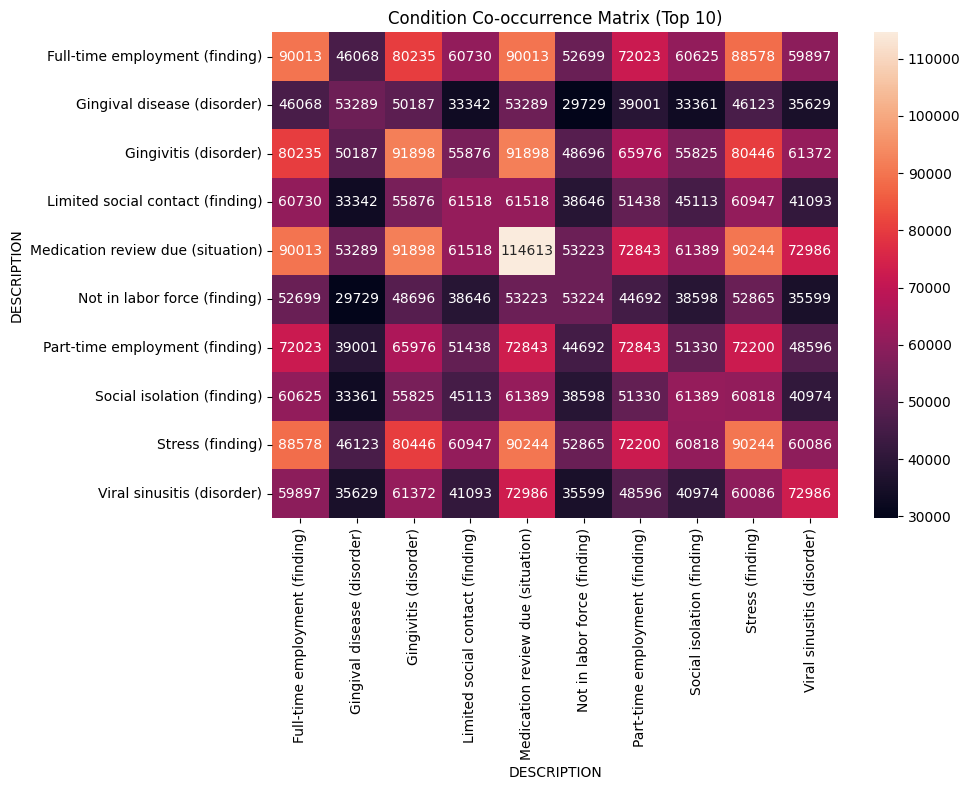

In [48]:
plt.figure(figsize=(10,8))
sns.heatmap(co_occurrence, annot=True, fmt="d")
plt.title("Condition Co-occurrence Matrix (Top 10)")
plt.tight_layout()
plt.show()

In [49]:
encounters = pd.read_csv(r"D:\DEPI\DEPI final project\data sources\encounters.csv")

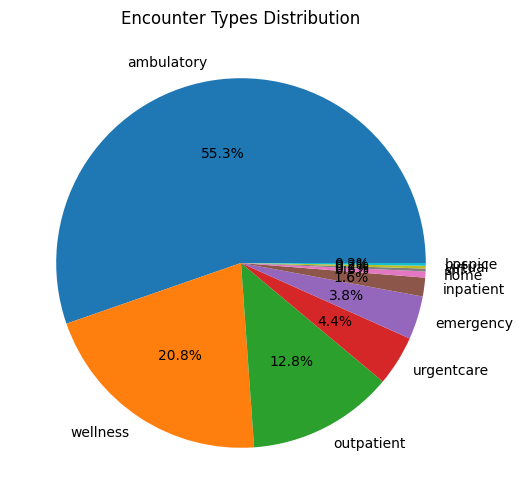

In [50]:
enc_type = encounters["ENCOUNTERCLASS"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(enc_type.values, labels=enc_type.index, autopct='%1.1f%%')
plt.title("Encounter Types Distribution")
plt.show()

In [51]:
encounters["START"] = pd.to_datetime(encounters["START"])
encounters["STOP"] = pd.to_datetime(encounters["STOP"])

encounters["duration_minutes"] = (
    encounters["STOP"] - encounters["START"]
).dt.total_seconds() / 60

print("Average Encounter Duration (minutes):",
      encounters["duration_minutes"].mean())

Average Encounter Duration (minutes): 350.9901655258609


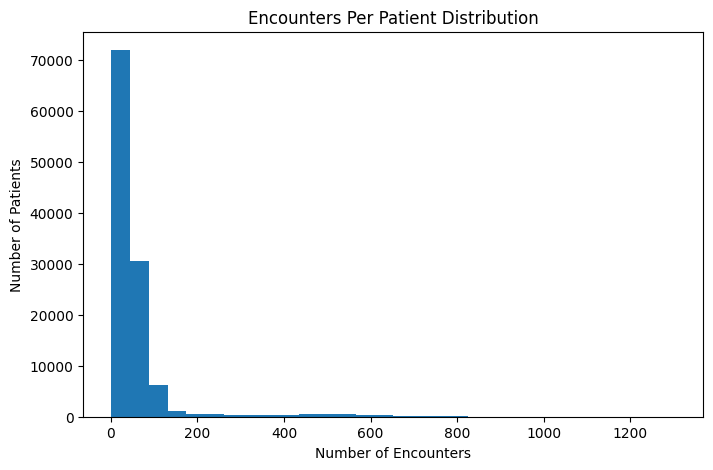

In [52]:
enc_per_patient = encounters["PATIENT"].value_counts()

plt.figure(figsize=(8,5))
plt.hist(enc_per_patient, bins=30)
plt.title("Encounters Per Patient Distribution")
plt.xlabel("Number of Encounters")
plt.ylabel("Number of Patients")
plt.show()

In [54]:
claims = pd.read_json(r"D:\DEPI\DEPI final project\env project\claims.json")
claims.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   claim_id       200000 non-null  str    
 1   patient_id     200000 non-null  str    
 2   encounter_id   200000 non-null  str    
 3   payer_name     200000 non-null  str    
 4   amount_billed  200000 non-null  float64
 5   amount_paid    200000 non-null  float64
 6   status         200000 non-null  str    
 7   denial_reason  35868 non-null   str    
dtypes: float64(2), str(6)
memory usage: 12.2 MB


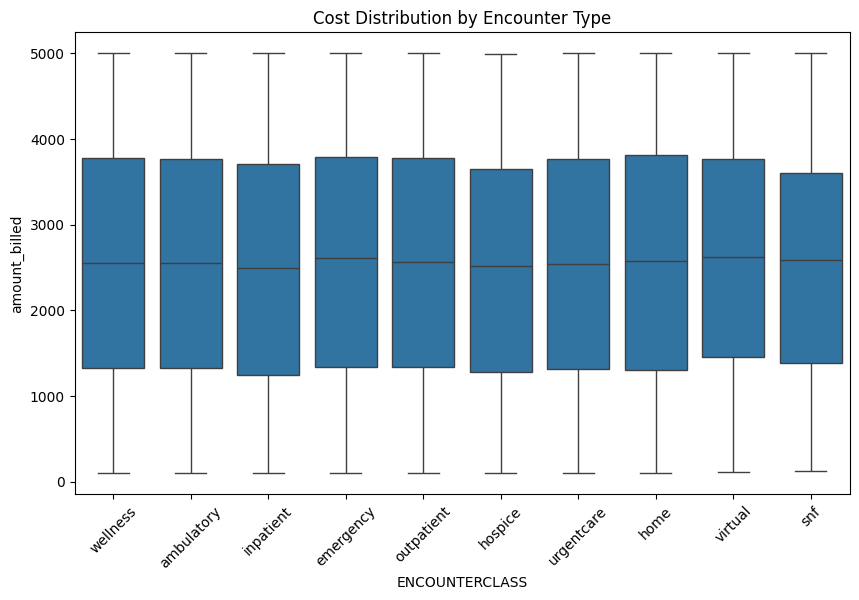

In [55]:
merged = encounters.merge(
    claims,
    left_on="Id",
    right_on="encounter_id",
    how="inner"
)

plt.figure(figsize=(10,6))
sns.boxplot(data=merged, x="ENCOUNTERCLASS", y="amount_billed")
plt.xticks(rotation=45)
plt.title("Cost Distribution by Encounter Type")
plt.show()

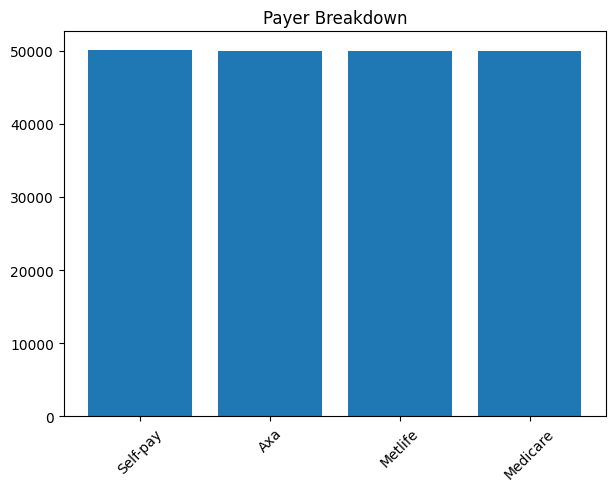

In [56]:
payer_counts = claims["payer_name"].value_counts()

plt.figure(figsize=(7,5))
plt.bar(payer_counts.index, payer_counts.values)
plt.xticks(rotation=45)
plt.title("Payer Breakdown")
plt.show()

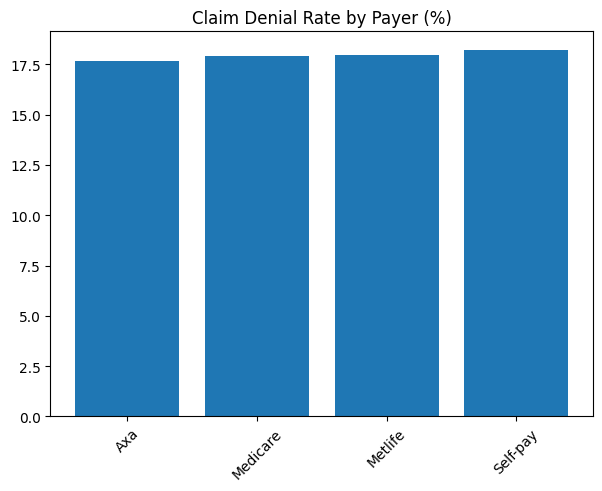

In [57]:
denial_rate = claims.groupby("payer_name")["status"] \
    .apply(lambda x: (x == "denied").mean()) * 100

plt.figure(figsize=(7,5))
plt.bar(denial_rate.index, denial_rate.values)
plt.xticks(rotation=45)
plt.title("Claim Denial Rate by Payer (%)")
plt.show()

In [58]:
medications = pd.read_csv(r"D:\DEPI\DEPI final project\data sources\medications.csv")
medications.info()

<class 'pandas.DataFrame'>
RangeIndex: 5668128 entries, 0 to 5668127
Data columns (total 13 columns):
 #   Column             Dtype  
---  ------             -----  
 0   START              str    
 1   STOP               str    
 2   PATIENT            str    
 3   PAYER              str    
 4   ENCOUNTER          str    
 5   CODE               int64  
 6   DESCRIPTION        str    
 7   BASE_COST          float64
 8   PAYER_COVERAGE     float64
 9   DISPENSES          int64  
 10  TOTALCOST          float64
 11  REASONCODE         float64
 12  REASONDESCRIPTION  str    
dtypes: float64(4), int64(2), str(7)
memory usage: 562.2 MB


In [59]:
medications.isnull().sum()

START                      0
STOP                  298281
PATIENT                    0
PAYER                      0
ENCOUNTER                  0
CODE                       0
DESCRIPTION                0
BASE_COST                  0
PAYER_COVERAGE             0
DISPENSES                  0
TOTALCOST                  0
REASONCODE           1035650
REASONDESCRIPTION    1035650
dtype: int64

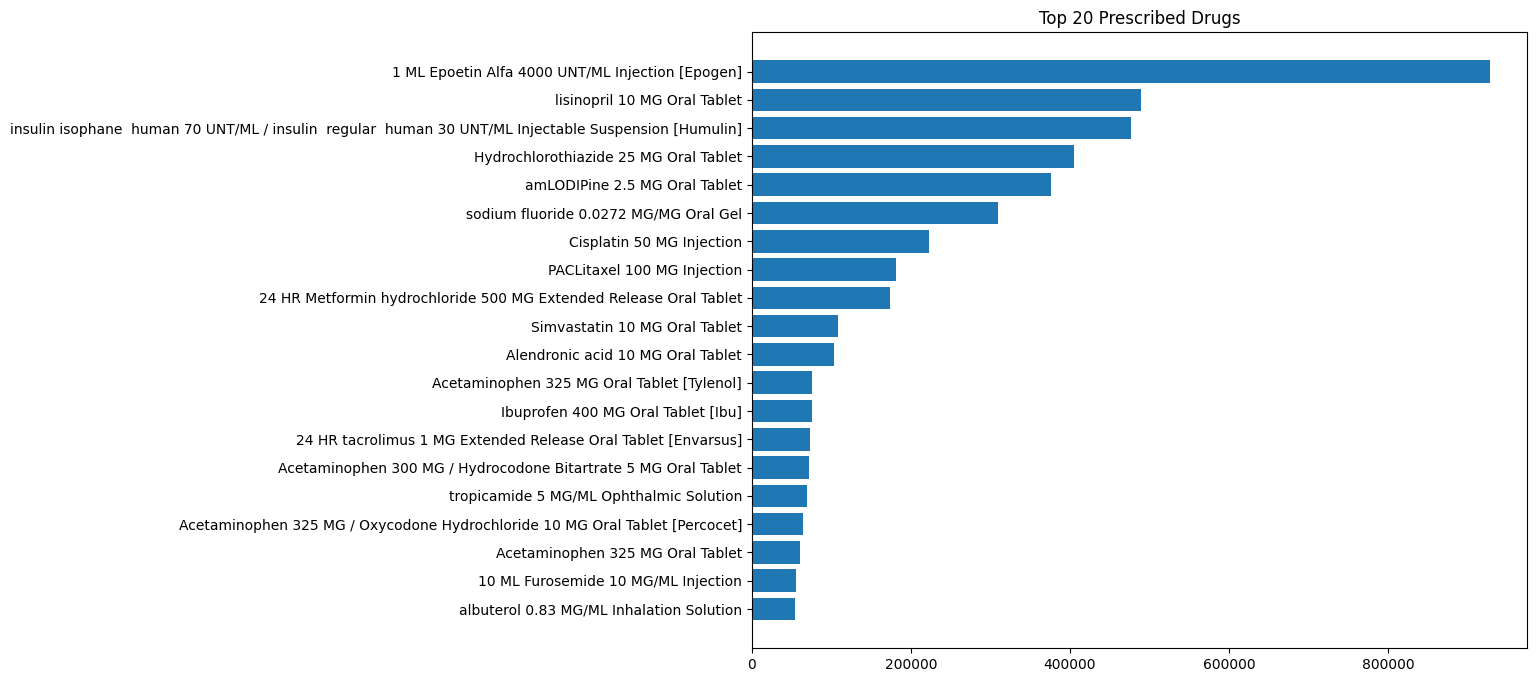

In [60]:
top_drugs = medications["DESCRIPTION"].value_counts().head(20)

plt.figure(figsize=(10,8))
plt.barh(top_drugs.index, top_drugs.values)
plt.gca().invert_yaxis()
plt.title("Top 20 Prescribed Drugs")
plt.show()

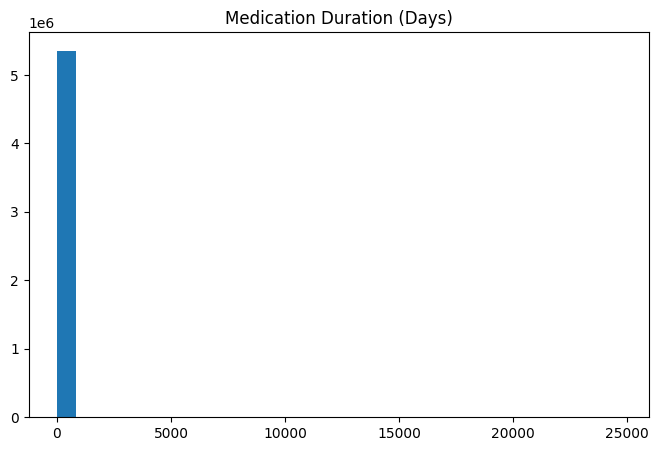

In [61]:
medications["START"] = pd.to_datetime(medications["START"])
medications["STOP"] = pd.to_datetime(medications["STOP"])

medications["duration_days"] = (
    medications["STOP"] - medications["START"]
).dt.days

plt.figure(figsize=(8,5))
plt.hist(medications["duration_days"].dropna(), bins=30)
plt.title("Medication Duration (Days)")
plt.show()

In [62]:
med_per_patient = medications.groupby("PATIENT")["DESCRIPTION"].nunique()

polypharmacy_rate = (med_per_patient >= 5).mean() * 100

print("Polypharmacy Rate (%):", polypharmacy_rate)

Polypharmacy Rate (%): 63.9352916439251


In [64]:
encounters.info()

<class 'pandas.DataFrame'>
RangeIndex: 6702719 entries, 0 to 6702718
Data columns (total 16 columns):
 #   Column               Dtype              
---  ------               -----              
 0   Id                   str                
 1   START                datetime64[us, UTC]
 2   STOP                 datetime64[us, UTC]
 3   PATIENT              str                
 4   ORGANIZATION         str                
 5   PROVIDER             str                
 6   PAYER                str                
 7   ENCOUNTERCLASS       str                
 8   CODE                 int64              
 9   DESCRIPTION          str                
 10  BASE_ENCOUNTER_COST  float64            
 11  TOTAL_CLAIM_COST     float64            
 12  PAYER_COVERAGE       float64            
 13  REASONCODE           float64            
 14  REASONDESCRIPTION    str                
 15  duration_minutes     float64            
dtypes: datetime64[us, UTC](2), float64(5), int64(1), str(8)
memory us

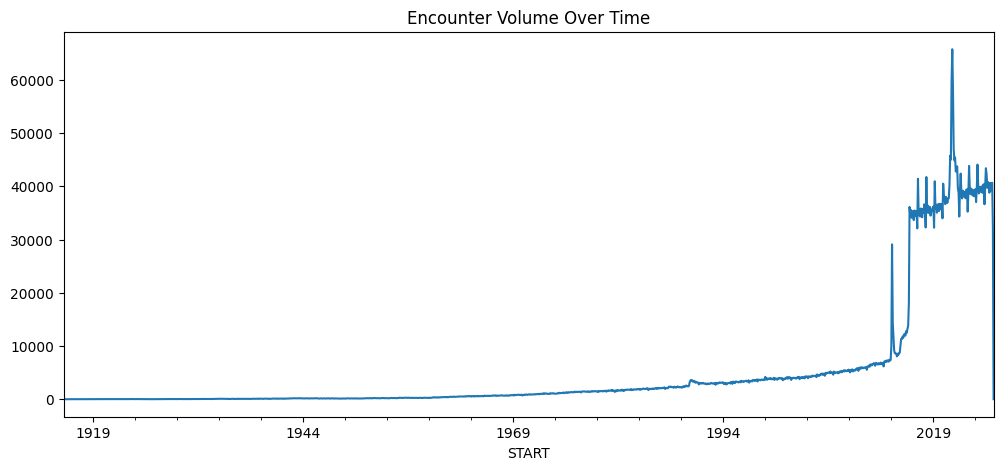

In [65]:
encounters["START"] = pd.to_datetime(encounters["START"])

monthly = encounters.set_index("START").resample("ME").size()

plt.figure(figsize=(12,5))
monthly.plot()
plt.title("Encounter Volume Over Time")
plt.show()

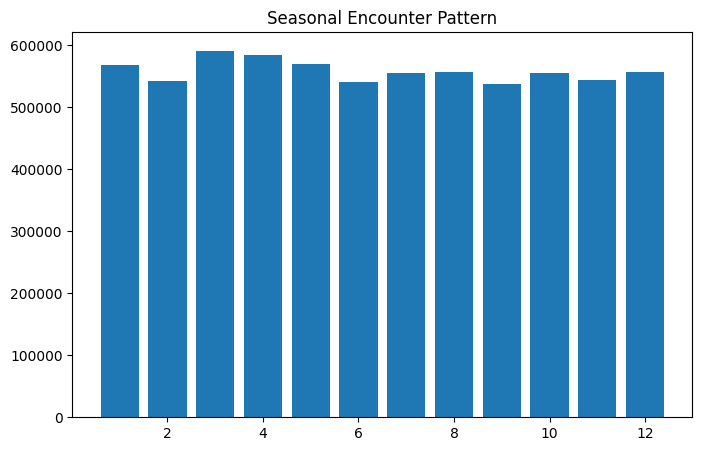

In [66]:
encounters["month"] = encounters["START"].dt.month

seasonal = encounters.groupby("month").size()

plt.figure(figsize=(8,5))
plt.bar(seasonal.index, seasonal.values)
plt.title("Seasonal Encounter Pattern")
plt.show()

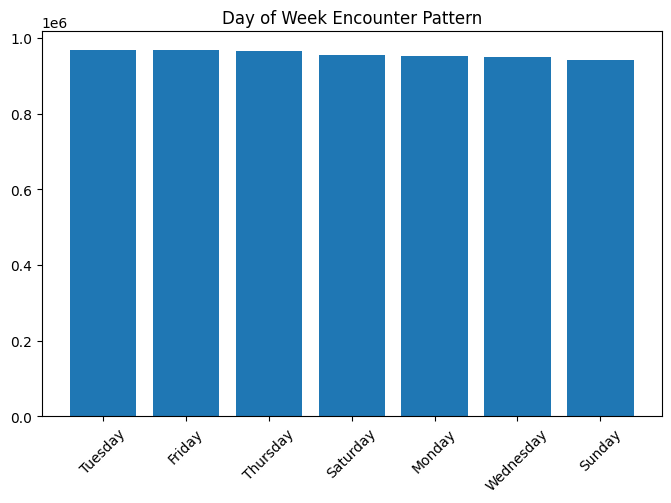

In [67]:
encounters["day_of_week"] = encounters["START"].dt.day_name()

dow = encounters["day_of_week"].value_counts()

plt.figure(figsize=(8,5))
plt.bar(dow.index, dow.values)
plt.xticks(rotation=45)
plt.title("Day of Week Encounter Pattern")
plt.show()

In [ ]:
#REPORTING TOOL NEED LOWER VERSION OF PYTHON